In [1]:
from google.colab import drive
drive.mount('/content/gdrive')
!ln -s /content/gdrive/My\ Drive/ /mydrive
%cd /mydrive/Hugging Face

Mounted at /content/gdrive
/content/gdrive/.shortcut-targets-by-id/1OAwQPoxfnPPp90tlzRE1fTmfB377ksLA/Hugging Face


In [3]:
import os
import json

def count_images(image_dir, exts={".jpg", ".jpeg", ".png", ".bmp", ".webp"}):
    image_count = 0
    for filename in os.listdir(image_dir):
        if os.path.splitext(filename.lower())[1] in exts:
            image_count += 1
    print(f"Total images: {image_count}")

count_images("markerpensseg/train")
count_images("markerpensseg/valid")

Total images: 225
Total images: 30


In [4]:
# Check train annotations
with open("markerpensseg/train/_annotations.coco.json") as f:
    train_data = json.load(f)
    print(f"Train images: {len(train_data['images'])}")
    print(f"Train annotations: {len(train_data['annotations'])}")
    print(f"Categories: {train_data['categories']}")

# Check validation
with open("markerpensseg/valid/_annotations.coco.json") as f:
    valid_data = json.load(f)
    print(f"\nValid images: {len(valid_data['images'])}")
    print(f"Valid annotations: {len(valid_data['annotations'])}")

Train images: 225
Train annotations: 450
Categories: [{'id': 0, 'name': 'caps-7o2C', 'supercategory': 'none'}, {'id': 1, 'name': 'CAP', 'supercategory': 'caps-7o2C'}]

Valid images: 30
Valid annotations: 60


In [5]:
import json
from collections import defaultdict
from pprint import pprint

def check_coco_instance_segmentation(ann_file_path):
    with open(ann_file_path, 'r') as f:
        coco_data = json.load(f)

    # Top-level keys
    assert 'images' in coco_data, "'images' key not found"
    assert 'annotations' in coco_data, "'annotations' key not found"
    assert 'categories' in coco_data, "'categories' key not found"

    print(f"📷 Total images: {len(coco_data['images'])}")
    print(f"✏️ Total annotations: {len(coco_data['annotations'])}")
    print(f"🏷️ Total categories: {len(coco_data['categories'])}")

    print("\n🔍 Sample category definitions:")
    pprint(coco_data['categories'])

    # Required annotation fields
    required_fields = {"id", "image_id", "bbox", "category_id", "segmentation"}
    optional_fields = ["iscrowd", "area"]
    missing_fields = defaultdict(list)
    bad_segmentations = []

    for i, ann in enumerate(coco_data['annotations']):
        for field in required_fields:
            if field not in ann:
                missing_fields[field].append(i)

        # Check segmentation format: must be non-empty polygon(s)
        seg = ann.get("segmentation", [])
        if not isinstance(seg, list) or len(seg) == 0:
            bad_segmentations.append((i, "Empty or invalid segmentation"))
        else:
            for poly in seg:
                if not isinstance(poly, list) or len(poly) < 6 or len(poly) % 2 != 0:
                    bad_segmentations.append((i, f"Invalid polygon: {poly}"))

    # Report missing fields
    for field, indices in missing_fields.items():
        print(f"⚠️ Missing '{field}' in {len(indices)} annotations. Examples: {indices[:5]}")
    if not missing_fields:
        print("✅ All required fields are present in every annotation")

    # Report segmentation issues
    if bad_segmentations:
        print(f"⚠️ Found {len(bad_segmentations)} invalid/malformed segmentations.")
        for i, reason in bad_segmentations[:5]:
            print(f"  Annotation {i}: {reason}")
    else:
        print("✅ All segmentations are well-formed polygons")

    # Optional fields
    for field in optional_fields:
        missing = sum(1 for ann in coco_data['annotations'] if field not in ann)
        if missing > 0:
            print(f"⚠️ Missing optional '{field}' in {missing} annotations")
        else:
            print(f"✅ All annotations have optional field '{field}'")

# Example usage:
check_coco_instance_segmentation("markerpensseg/train/_annotations.coco.json")

📷 Total images: 225
✏️ Total annotations: 450
🏷️ Total categories: 2

🔍 Sample category definitions:
[{'id': 0, 'name': 'caps-7o2C', 'supercategory': 'none'},
 {'id': 1, 'name': 'CAP', 'supercategory': 'caps-7o2C'}]
✅ All required fields are present in every annotation
✅ All segmentations are well-formed polygons
✅ All annotations have optional field 'iscrowd'
✅ All annotations have optional field 'area'


In [ ]:
!pip install -U 'git+https://github.com/facebookresearch/detectron2.git'

In [7]:
import detectron2
from detectron2.utils.logger import setup_logger
setup_logger()

<Logger detectron2 (DEBUG)>

In [9]:
from detectron2.data.datasets import register_coco_instances
import os

data_dir = "markerpensseg"

register_coco_instances("marker_train", {},
                        os.path.join(data_dir, "train/_annotations.coco.json"),
                        os.path.join(data_dir, "train"))

register_coco_instances("marker_val", {},
                        os.path.join(data_dir, "valid/_annotations.coco.json"),
                        os.path.join(data_dir, "valid"))

In [65]:
from detectron2.config import get_cfg
from detectron2 import model_zoo

cfg = get_cfg()

# Use Cascade Mask R-CNN with ResNet-50
cfg.merge_from_file(model_zoo.get_config_file("Misc/cascade_mask_rcnn_R_50_FPN_3x.yaml"))
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("Misc/cascade_mask_rcnn_R_50_FPN_3x.yaml")

# Dataset
cfg.DATASETS.TRAIN = ("marker_train",)
cfg.DATASETS.TEST = ("marker_val",)
cfg.DATALOADER.NUM_WORKERS = 2

# Training setup
cfg.SOLVER.IMS_PER_BATCH = 8
num_images = 225
epochs = 50
iters_per_epoch = num_images // cfg.SOLVER.IMS_PER_BATCH
cfg.SOLVER.MAX_ITER = iters_per_epoch * epochs
# Dynamic LR step schedule (50% and 80% of total iters)
cfg.SOLVER.BASE_LR = 0.00025
cfg.SOLVER.STEPS = (
    int(cfg.SOLVER.MAX_ITER * 0.5),
    int(cfg.SOLVER.MAX_ITER * 0.8)
)
# Evaluate every 2 epochs
cfg.TEST.EVAL_PERIOD = iters_per_epoch * 5 # 5 epoch
cfg.SOLVER.GAMMA = 0.1

cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 128
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 2
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.35
cfg.MODEL.ROI_HEADS.NMS_THRESH_TEST = 0.5

cfg.SOLVER.CHECKPOINT_PERIOD = iters_per_epoch * 5 # 5 epoch
cfg.OUTPUT_DIR = "/content/.cache/detectron2_marker"
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

In [66]:
from detectron2.engine import DefaultTrainer, hooks
from detectron2.evaluation import COCOEvaluator
import torch

from detectron2.evaluation import inference_on_dataset

class BestModelSaver(hooks.EvalHook):
    def __init__(self, eval_period, model, evaluator, val_loader, save_path):
        self.model = model
        self.evaluator = evaluator
        self.val_loader = val_loader
        self.save_path = save_path
        self.best_ap = -1

        def eval_function():
            results = inference_on_dataset(self.model, self.val_loader, self.evaluator)
            if results:
                curr_ap = results["bbox"]["AP"]
                print(f"📈 Eval AP: {curr_ap:.4f} | Best so far: {self.best_ap:.4f}")
                if curr_ap > self.best_ap:
                    print(f"🥇 New best model! Saving to {self.save_path}")
                    torch.save(self.model.state_dict(), self.save_path)
                    self.best_ap = curr_ap
            return results

        super().__init__(eval_period, eval_function)

In [67]:
from detectron2.evaluation import COCOEvaluator, inference_on_dataset
from pycocotools.coco import COCO
import copy

class SafeCOCOEvaluator(COCOEvaluator):
    def _evaluate_predictions_on_coco(self, coco_gt: COCO, coco_results, iou_type):
        # 🔧 Patch missing fields to prevent crashing
        coco_gt.dataset.setdefault("info", {})
        coco_gt.dataset.setdefault("licenses", [])
        coco_gt.createIndex()  # Ensure internal COCO indexing is rebuilt

        coco_dt = coco_gt.loadRes(coco_results)
        return super()._evaluate_predictions_on_coco(coco_gt, coco_dt, iou_type)

In [93]:
torch.cuda.empty_cache()

In [68]:
from detectron2.data import build_detection_test_loader

trainer = DefaultTrainer(cfg)

val_loader = build_detection_test_loader(cfg, "marker_val")
evaluator = SafeCOCOEvaluator("marker_val", cfg, False, output_dir=cfg.OUTPUT_DIR)
best_model_path = "datasets/best_cascade_maskrcnn_marker.pth"

trainer.register_hooks([
    BestModelSaver(cfg.TEST.EVAL_PERIOD, trainer.model, evaluator, val_loader, best_model_path)
])

from pycocotools.coco import COCO
import copy
import json
import time

def patched_loadRes(self, resFile):
    tic = time.time()  # <-- ✅ define it properly now

    # Ensure required dataset fields exist
    if 'info' not in self.dataset:
        self.dataset['info'] = {}
    if 'licenses' not in self.dataset:
        self.dataset['licenses'] = []

    # Load annotation results from file or list
    if isinstance(resFile, str):
        with open(resFile, 'r') as f:
            anns = json.load(f)
    elif isinstance(resFile, list):
        anns = resFile
    else:
        raise TypeError('resFile must be a file path or list of dicts')

    res = COCO()
    res.dataset['info'] = copy.deepcopy(self.dataset['info'])
    res.dataset['licenses'] = copy.deepcopy(self.dataset['licenses'])
    res.dataset['images'] = copy.deepcopy(self.dataset['images'])

    assert isinstance(anns, list), 'Annotations must be a list'
    anns_img_ids = [ann['image_id'] for ann in anns]
    assert set(anns_img_ids).issubset(set(self.getImgIds()))

    # Add missing 'id' and 'area' fields in each annotation
    for idx, ann in enumerate(anns):
        ann.setdefault('id', idx + 1)
        if 'area' not in ann:
            if 'bbox' in ann:
                _, _, w, h = ann['bbox']
                ann['area'] = w * h
            else:
                ann['area'] = 0

    res.dataset['annotations'] = anns
    res.createIndex()
    print(f'Annotations loaded in {time.time() - tic:.2f}s')
    return res

# ✅ Monkey-patch the method
COCO.loadRes = patched_loadRes

[03/30 16:28:44 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res

In [69]:
trainer.resume_or_load(resume=True)
trainer.train()

[03/30 16:28:48 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /content/.cache/detectron2_marker/model_final.pth ...
[03/30 16:28:49 d2.engine.hooks]: Loading scheduler from state_dict ...
[03/30 16:28:49 d2.engine.train_loop]: Starting training from iteration 840
[03/30 16:29:41 d2.utils.events]:  eta: 0:23:27  iter: 859  total_loss: 3.307  loss_cls_stage0: 0.5328  loss_box_reg_stage0: 0.2954  loss_cls_stage1: 0.5362  loss_box_reg_stage1: 0.387  loss_cls_stage2: 0.5602  loss_box_reg_stage2: 0.3741  loss_mask: 0.519  loss_rpn_cls: 0.04295  loss_rpn_loc: 0.01264    time: 2.5836  last_time: 2.6250  data_time: 0.4640  last_data_time: 0.3725   lr: 2.151e-05  max_mem: 9643M
[03/30 16:30:34 d2.utils.events]:  eta: 0:22:30  iter: 879  total_loss: 3.062  loss_cls_stage0: 0.5081  loss_box_reg_stage0: 0.2806  loss_cls_stage1: 0.511  loss_box_reg_stage1: 0.3513  loss_cls_stage2: 0.5392  loss_box_reg_stage2: 0.3747  loss_mask: 0.4719  loss_rpn_cls: 0.02863  loss_rpn_loc:

In [70]:
from detectron2.config import get_cfg
from detectron2.engine import DefaultTrainer, DefaultPredictor
from detectron2.data import build_detection_test_loader
from detectron2.evaluation import COCOEvaluator, inference_on_dataset
from detectron2 import model_zoo
import os

# 🔧 Setup config
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("Misc/cascade_mask_rcnn_R_50_FPN_3x.yaml"))
cfg.DATALOADER.NUM_WORKERS = 2
cfg.MODEL.WEIGHTS = "datasets/best_cascade_maskrcnn_marker.pth"
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.35  # confidence threshold
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 2

# 🧪 Run evaluation
evaluator = COCOEvaluator("marker_val", cfg, False, output_dir="./output")
val_loader = build_detection_test_loader(cfg, "marker_val")
results = inference_on_dataset(DefaultPredictor(cfg).model, val_loader, evaluator)

print("\n📊 Evaluation Results on Saved Best Model:")
print(results)

WARNING [03/30 17:04:44 d2.evaluation.coco_evaluation]: COCO Evaluator instantiated using config, this is deprecated behavior. Please pass in explicit arguments instead.
WARNING [03/30 17:04:44 d2.data.datasets.coco]: 
Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.

[03/30 17:04:44 d2.data.datasets.coco]: Loaded 30 images in COCO format from markerpensseg/valid/_annotations.coco.json
[03/30 17:04:44 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
[03/30 17:04:44 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[03/30 17:04:44 d2.data.common]: Serializing 30 elements to byte tensors and concatenating them all ...
[03/30 17:04:44 d2.data.common]: Serialized dataset takes 0.03 MiB
[03/30 17:04:45 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from datasets/best_

In [75]:
import random
import cv2
import matplotlib.pyplot as plt
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2 import model_zoo
from detectron2.utils.visualizer import Visualizer, ColorMode
from detectron2.data import MetadataCatalog, DatasetCatalog
import os
import math

def run_inference_on_random_images(num_images):
    # --- Setup config and predictor ---
    cfg = get_cfg()
    cfg.merge_from_file(model_zoo.get_config_file("Misc/cascade_mask_rcnn_R_50_FPN_3x.yaml"))
    cfg.MODEL.WEIGHTS = "datasets/best_cascade_maskrcnn_marker.pth"
    cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.7
    cfg.MODEL.ROI_HEADS.NMS_THRESH_TEST = 0.3
    cfg.MODEL.DEVICE = "cuda"
    cfg.MODEL.ROI_HEADS.NUM_CLASSES = 2

    predictor = DefaultPredictor(cfg)

    # Assign fixed colors to each category (DO NOT touch class names)
    fixed_colors = [
        (0, 0, 0),     # bg
        (0, 255, 0),     # green
    ]
    MetadataCatalog.get("marker_val").thing_colors = fixed_colors

    metadata = MetadataCatalog.get("marker_val")
    dataset_dicts = DatasetCatalog.get("marker_val")
    sampled_dicts = random.sample(dataset_dicts, num_images)

    # Prepare grid layout
    cols = 4
    rows = math.ceil(num_images / cols)
    plt.figure(figsize=(cols * 4, 6 * rows))

    for idx, d in enumerate(sampled_dicts):
        img_path = d["file_name"]
        img = cv2.imread(img_path)
        outputs = predictor(img)

        v = Visualizer(
            img[:, :, ::-1],
            metadata=metadata,
            scale=0.5,
            instance_mode=ColorMode.SEGMENTATION,
        )
        height, width, channels = img.shape
        if width > 800:
            v._default_line_width = 10 # your desired bounding box thickness
            # override default font size:
            v._default_font_size = 60  # increase font size for labels
        else:
            v._default_line_width = 5 # your desired bounding box thickness
            # override default font size:
            v._default_font_size = 20  # increase font size for labels

        # Set mask transparency here:
        v._default_alpha = 0.3  # from 0 (transparent) to 1 (opaque)

        # Draw predictions
        v = v.draw_instance_predictions(outputs["instances"].to("cpu"))

        plt.subplot(rows, cols, idx + 1)
        plt.imshow(v.get_image())
        plt.axis("off")
        plt.title(f"Image {idx + 1}")

    plt.tight_layout()
    plt.show()

[03/30 17:08:17 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from datasets/best_cascade_maskrcnn_marker.pth ...
WARNING [03/30 17:08:17 d2.data.datasets.coco]: 
Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.

[03/30 17:08:17 d2.data.datasets.coco]: Loaded 30 images in COCO format from markerpensseg/valid/_annotations.coco.json


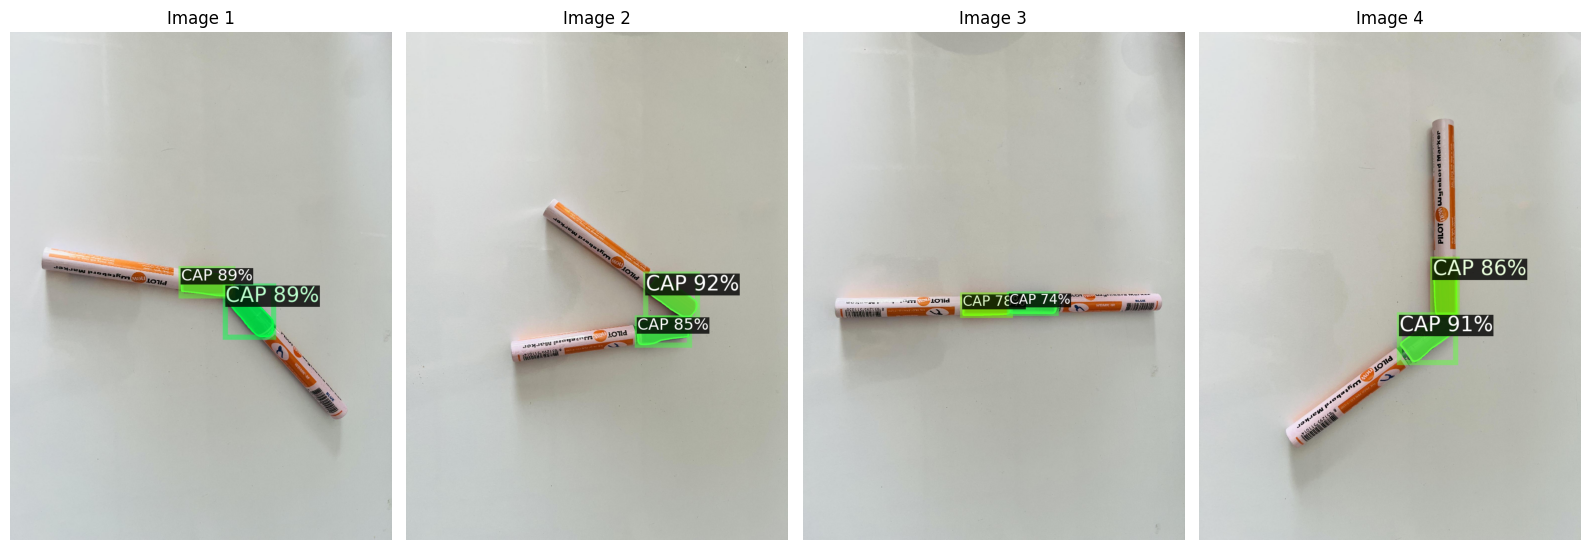

In [79]:
run_inference_on_random_images(4)

In [127]:
from detectron2.modeling import build_model
from detectron2.export import TracingAdapter
from detectron2.checkpoint import DetectionCheckpointer

cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("Misc/cascade_mask_rcnn_R_50_FPN_3x.yaml"))
cfg.MODEL.WEIGHTS = "datasets/best_cascade_maskrcnn_marker.pth"
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5
cfg.MODEL.ROI_HEADS.NMS_THRESH_TEST = 0.3
cfg.MODEL.DEVICE = "cuda"
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 2

model = build_model(cfg)
model.eval()

checkpointer = DetectionCheckpointer(model)
checkpointer.load("datasets/best_cascade_maskrcnn_marker.pth")

[03/30 17:34:32 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from datasets/best_cascade_maskrcnn_marker.pth ...


{}

In [128]:
import torch
import torch.nn as nn

class D2MaskRCNNWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, image):
        inputs = [{"image": image}]
        images = self.model.preprocess_image(inputs)

        features = self.model.backbone(images.tensor)
        proposals, _ = self.model.proposal_generator(images, features, None)
        results, _ = self.model.roi_heads(images, features, proposals, None)

        inst = results[0]

        masks = inst.pred_masks if inst.has("pred_masks") else torch.empty(0,1,28,28)

        return (
            masks.float(),
            inst.pred_boxes.tensor,
            inst.pred_classes,
            inst.scores,
        )

# Use the wrapper for export
wrapped_model = D2MaskRCNNWrapper(model)
wrapped_model.eval()

D2MaskRCNNWrapper(
  (model): GeneralizedRCNN(
    (backbone): FPN(
      (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
      (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
      (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
      (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
      (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (top_block): LastLevelMaxPool()
      (bottom_up): ResNet(
        (stem): BasicStem(
          (conv1): Conv2d(
            3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
            (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
          )


In [129]:
dummy = torch.randn(3, 640, 640).to(cfg.MODEL.DEVICE)

with torch.no_grad():
    masks, boxes, labels, scores = wrapped_model(dummy)

print("masks:", masks.shape)
print("boxes:", boxes.shape)
print("labels:", labels.shape)
print("scores:", scores.shape)

masks: torch.Size([0, 1, 28, 28])
boxes: torch.Size([0, 4])
labels: torch.Size([0])
scores: torch.Size([0])


In [130]:
import cv2
import torch

img = cv2.imread("markerpensseg/valid/1B3246F6-8785-4465-AC56-3BE7AA44003D_jpeg.rf.ddd6b9b6921d9589dfae0019661b06a1.jpg")
img = cv2.resize(img, (640,640))

img = torch.as_tensor(img.transpose(2,0,1)).float().to(cfg.MODEL.DEVICE)

with torch.no_grad():
    out = wrapped_model(img)

print(out[0].shape, out[1].shape)

dummy_image = img

torch.Size([2, 1, 28, 28]) torch.Size([2, 4])


In [85]:
!pip install onnx onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 81.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 15.2 MB/s eta 0:00:00


In [135]:
onnx_model_path = "datasets/best_cascade_maskrcnn_marker.onnx"

dynamic_axes = {
    "masks": {0: "num_instances"},
    "boxes": {0: "num_instances"},
    "labels": {0: "num_instances"},
    "scores": {0: "num_instances"},
}

torch.onnx.export(
    wrapped_model,
    (dummy_image,),
    onnx_model_path,
    opset_version=17,
    dynamo=False,        # Use legacy exporter to avoid strict tracing issues
    input_names=["input"],
    output_names=["masks", "boxes", "labels", "scores"],
    dynamic_axes=dynamic_axes,
    do_constant_folding=False,
)
print(f"ONNX export {onnx_model_path} completed successfully!")

/tmp/ipykernel_1640/669523253.py:10: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(
/usr/local/lib/python3.12/dist-packages/detectron2/structures/image_list.py:86: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  assert t.shape[:-2] == tensors[0].shape[:-2], t.shape
/usr/local/lib/python3.12/dist-packages/detectron2/structures/boxes.py:151: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be in

ONNX export datasets/best_cascade_maskrcnn_marker.onnx completed successfully!


In [87]:
!pip install onnxruntime-gpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.8/252.8 MB 1.5 MB/s eta 0:00:00


In [136]:
import onnxruntime
import numpy as np
import cv2
import os
import random
import torch

# Load image and preprocess (assume 640x640)
img_path = "markerpensseg/valid/1B3246F6-8785-4465-AC56-3BE7AA44003D_jpeg.rf.ddd6b9b6921d9589dfae0019661b06a1.jpg"

img = cv2.imread(img_path)
img_resized = cv2.resize(img, (640, 640))
img_input = img_resized.astype(np.float32)
img_input = img_input.transpose(2, 0, 1)  # Result: (3, 640, 640)

# Run inference
session = onnxruntime.InferenceSession("datasets/best_cascade_maskrcnn_marker.onnx", providers=["CUDAExecutionProvider"])
input_name = session.get_inputs()[0].name
outputs = session.run(None, {input_name: img_input})

# outputs is a list, often like [boxes, scores, keypoints]
print("Output:", [o.shape for o in outputs])

Output: [(2, 1, 28, 28), (2, 4), (2,), (2,)]


[1 1]
[0.8719206  0.72697735]


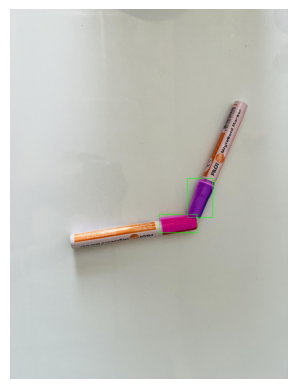

In [137]:
import torch
from torchvision.ops import nms
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Unpack outputs correctly
masks, boxes, labels, scores = outputs

# Convert to numpy arrays if needed
boxes = np.array(boxes)
labels = np.array(labels)
scores = np.array(scores)

# Apply NMS
boxes_tensor = torch.tensor(boxes, dtype=torch.float32)
scores_tensor = torch.tensor(scores, dtype=torch.float32)
nms_indices = nms(boxes_tensor, scores_tensor, iou_threshold=0.5)

# Filter after NMS
boxes = boxes_tensor[nms_indices].numpy()
scores = scores_tensor[nms_indices].numpy()
labels = labels[nms_indices]
masks = masks[nms_indices]
print(labels)
print(scores)

# Resize back to original scale
h_orig, w_orig = img.shape[:2]
scale_x = w_orig / 640  # width scale
scale_y = h_orig / 640  # height scale

conf_thr = 0.5

for i in range(len(scores)):
    if scores[i] < conf_thr:
        continue

    # Draw bounding box
    x1, y1, x2, y2 = boxes[i]
    x1 = int(x1 * scale_x)
    y1 = int(y1 * scale_y)
    x2 = int(x2 * scale_x)
    y2 = int(y2 * scale_y)

    x1 = max(0, min(x1, w_orig - 1))
    y1 = max(0, min(y1, h_orig - 1))
    x2 = max(0, min(x2, w_orig - 1))
    y2 = max(0, min(y2, h_orig - 1))

    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

    mask_28 = masks[i, 0] # Assuming shape is (1, 28, 28)

    # Resize mask to bounding box size
    box_w = max(x2 - x1, 1)
    box_h = max(y2 - y1, 1)

    mask_resized = cv2.resize(mask_28, (box_w, box_h), interpolation=cv2.INTER_LINEAR)
    mask_bool_small = mask_resized > 0.5

    # Paste into full image mask
    mask_bool = np.zeros((h_orig, w_orig), dtype=bool)
    mask_bool[y1:y2, x1:x2] = mask_bool_small[:(y2-y1), :(x2-x1)]

    # Generate color (BGR)
    color = [255,0,255]

    # Create colored mask with the random color
    colored_mask = np.zeros_like(img, dtype=np.uint8)
    for c in range(3):
        colored_mask[:, :, c] = mask_bool * color[c]

    # Alpha blend the colored mask onto the overlay
    alpha = 0.4
    img = np.where(mask_bool[:, :, None],
                      (((1 - alpha) * img) + (alpha * colored_mask)).astype(np.uint8),
                      img)

# Show result
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

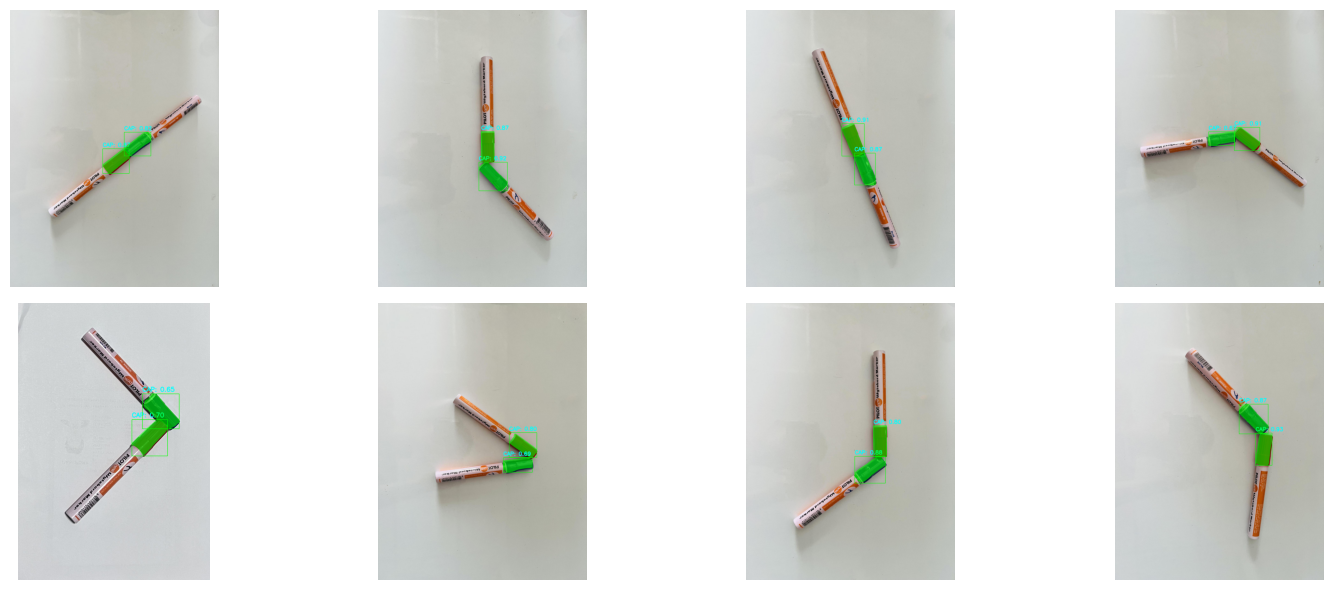

In [140]:
# class names
label_list= ["", "CAP"]

# Assign fixed colors to each category
fixed_colors = [
        (0, 0, 0),     # bg
        (0, 255, 0),     # green
    ]

# ---------------- CONFIG ----------------
val_dir = "markerpensseg/valid/"

# visualization layout
N = 8
cols = 4
rows = int(np.ceil(N / cols))

# random image selection
all_imgs = [os.path.join(val_dir, f)
            for f in os.listdir(val_dir)
            if f.lower().endswith((".jpg", ".png", ".jpeg"))]

sample_imgs = random.sample(all_imgs, N)

plt.figure(figsize=(4 * cols, 3 * rows))

for i, image in enumerate(sample_imgs):
    plt.subplot(2, 4, i+1)

    img = cv2.imread(image)
    img_resized = cv2.resize(img, (640, 640))
    img_input = img_resized.astype(np.float32)
    img_input = img_input.transpose(2, 0, 1)
    input_name = session.get_inputs()[0].name

    outputs = session.run(None, {input_name: img_input})

    masks, boxes, labels, scores = outputs

    # Convert to numpy arrays if needed
    boxes = np.array(boxes)
    labels = np.array(labels)
    scores = np.array(scores)

    # Resize back to original scale
    h_orig, w_orig = img.shape[:2]
    scale_x = w_orig / 640  # width scale
    scale_y = h_orig / 640  # height scale

    num_det = min(len(boxes), len(masks), len(scores), len(labels))

    boxes = boxes[:num_det]
    scores = scores[:num_det]
    labels = labels[:num_det]
    masks = masks[:num_det]

    # Apply NMS
    boxes_tensor = torch.tensor(boxes, dtype=torch.float32)
    scores_tensor = torch.tensor(scores, dtype=torch.float32)
    nms_indices = nms(boxes_tensor, scores_tensor, iou_threshold=0.5)

    # Filter after NMS
    boxes = boxes_tensor[nms_indices].numpy()
    scores = scores_tensor[nms_indices].numpy()
    labels = labels[nms_indices]
    masks = masks[nms_indices]

    boxes = np.array(boxes)
    scores = np.array(scores).reshape(-1)
    labels = np.array(labels).reshape(-1)
    masks = np.array(masks)

    # ensure dimensions exist
    if boxes.ndim == 1:
        boxes = boxes[None, :]
    if masks.ndim == 3:
        masks = masks[None, :]

    num_det = min(len(boxes), len(masks), len(scores), len(labels))

    boxes = boxes[:num_det]
    scores = scores[:num_det]
    labels = labels[:num_det]
    masks = masks[:num_det]

    conf_thr = 0.5

    keep = scores > conf_thr

    boxes = boxes[keep]
    scores = scores[keep]
    labels = labels[keep]
    masks = masks[keep]

    for ii in range(num_det):

        score = scores[ii]

        # Draw bounding box
        x1, y1, x2, y2 = boxes[ii]
        x1 = int(x1 * scale_x)
        y1 = int(y1 * scale_y)
        x2 = int(x2 * scale_x)
        y2 = int(y2 * scale_y)

        x1 = max(0, min(x1, w_orig - 1))
        y1 = max(0, min(y1, h_orig - 1))
        x2 = max(0, min(x2, w_orig - 1))
        y2 = max(0, min(y2, h_orig - 1))

        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

        mask_28 = masks[ii, 0] # Assuming shape is (1, 28, 28)

        # Resize mask to bounding box size
        box_w = max(x2 - x1, 1)
        box_h = max(y2 - y1, 1)

        mask_resized = cv2.resize(mask_28, (box_w, box_h), interpolation=cv2.INTER_LINEAR)
        mask_bool_small = mask_resized > 0.5

        # Paste into full image mask
        mask_bool = np.zeros((h_orig, w_orig), dtype=bool)
        mask_bool[y1:y2, x1:x2] = mask_bool_small[:(y2-y1), :(x2-x1)]

        # Generate color (BGR)
        label_id = int(labels[ii])
        color = fixed_colors[label_id]

        label = label_list[label_id]

        colored_mask = np.zeros_like(img, dtype=np.uint8)
        colored_mask[mask_bool] = color

        # Alpha blend the colored mask onto the overlay
        alpha = 0.6
        img = np.where(mask_bool[:, :, None],
                          (((1 - alpha) * img) + (alpha * colored_mask)).astype(np.uint8),
                          img)
        # draw label and score
        text = f"{label}: {score:.2f}"
        cv2.putText(img, text, (x1, y1 - 15), cv2.FONT_HERSHEY_SIMPLEX,
                    1.3, (255, 255, 0), 3, cv2.LINE_AA)

    plt.subplot(rows, cols, i + 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# there might be this static shape error even though exported with dynamic shapes
'''
Fail: [ONNXRuntimeError] : 1 : FAIL : Non-zero status code returned while running Split node.
Name:'/roi_heads/mask_head/Split' Status Message: Cannot split using values in 'split' attribute.
Axis=0 Input shape={3,1,28,28} NumOutputs=1 Num entries in 'split' (must equal number of outputs) was 1
Sum of sizes in 'split' (must equal size of selected axis) was 2
'''